In [319]:
#Jupyter Notebook for Acoustics Experiment in Physics Lab III
import numpy as np
import matplotlib.pyplot as plt

#plots
plt.rcParams['figure.dpi'] = 120
plt.rcParams.update({'font.size':12, 'font.family':'serif'}) #Setting fonts
plt.rcParams['text.usetex'] = False

import string #For figure labels

def rsq(y, y_fit):
    y = np.asarray(y)
    y_fit = np.asarray(y_fit)

    ss_res = np.sum((y - y_fit)**2)          # Residual sum of squares
    ss_tot = np.sum((y - np.mean(y))**2)     # Total sum of squares
    val = 1 - ss_res / ss_tot
    return val

# Part I - Melde's Vibrator

## Parallel Configuration

In [320]:
M_nocup = np.array([145.2,33.2,11.5,4.8755,1.4732,0])
M= (M_nocup + 3.565)/1000 #adding offset of cup weight
g = 9.81
T = M*g
p = np.array([1,2,3,4,5,6])

In [321]:
stringmass = 0.261/1000
length = 135.5 / 100
m = stringmass/length
L = 85.5 / 100 #L value from two ends

In [322]:
r = T/m

In [323]:
sqrts = r**(1/2)
yfinal = (1/(2*L))*sqrts
xfinal = 1/p

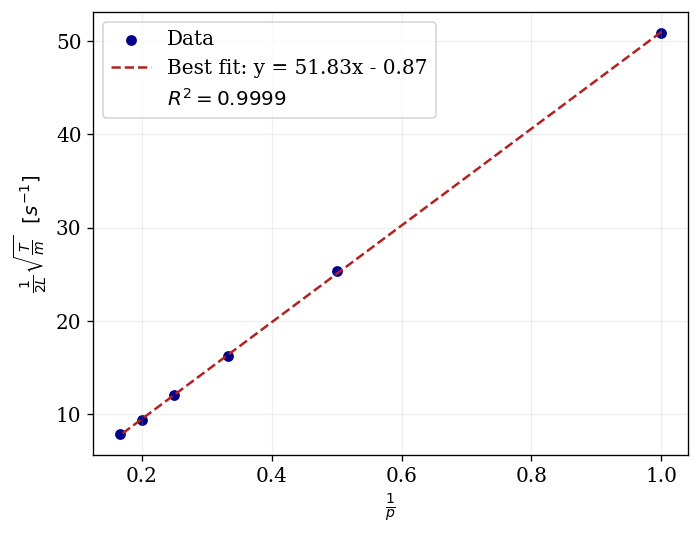

In [324]:
plt.scatter(xfinal, yfinal, label="Data",c="darkblue",s=30)
plt.xlabel(r"$\frac{1}{p}$")
plt.ylabel(r"$\frac{1}{2L}\sqrt{\frac{T}{m}} \ \ [s^{-1}]$")

m1,c1 = np.polyfit(xfinal, yfinal, deg=1)
y_fit1 = m1*xfinal + c1
rsq1 = rsq(yfinal, y_fit1)

plt.plot(xfinal, y_fit1, ls="--", c="firebrick",label=fr"Best fit: y = {m1:.2f}x - {abs(c1):.2f}")
plt.plot([], [], ' ', label=fr"$R^2 = {rsq1:.4f}$")
plt.legend()
plt.grid(alpha=0.2)
# plt.savefig("Transverse.jpg")

In [325]:
#Percentage Error:
err1 = (m1 - 50)/50 * 100
print('Percentage Error:',err1.round(3),'%')

Percentage Error: 3.657 %


## Perpendicular Configuration

In [326]:
M_perp_nocup = np.array([34.7105,5.861,0.8753])
M_perp = (M_perp_nocup + 3.565)/1000 #adding offset of cup weight
T2 = M_perp*g
p2 = np.array([1,2,3])

In [327]:
L2 = 90.8 / 100
r2 = T2/m
sqrts2 = r2**(1/2)
yperp = (1/(2*L2))*sqrts2
xperp = 1/p2

24.15060649141899


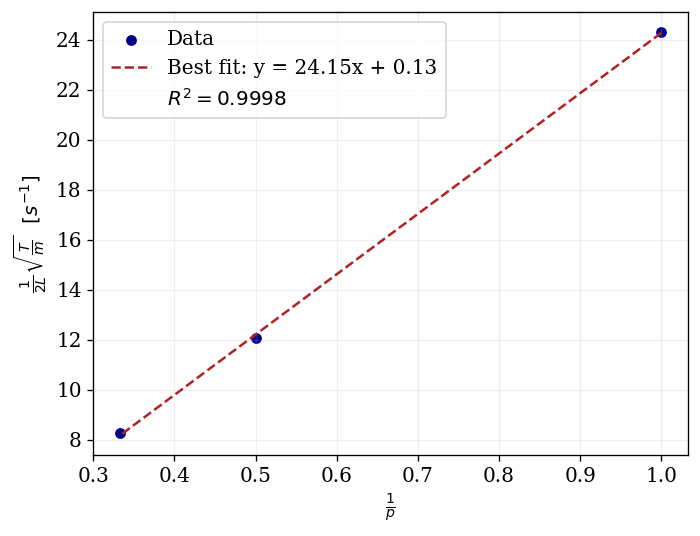

In [328]:
plt.scatter(xperp, yperp, label="Data",c="darkblue",s=30)
plt.xlabel(r"$\frac{1}{p}$")
plt.ylabel(r"$\frac{1}{2L}\sqrt{\frac{T}{m}} \ \ [s^{-1}]$")

m2,c2 = np.polyfit(xperp, yperp, deg=1)
y_fit2 = m2*xperp + c2
rsq2 = rsq(yperp, y_fit2)

plt.plot(xperp, y_fit2, ls="--", c="firebrick",label=fr"Best fit: y = {m2:.2f}x + {c2:.2f}")
plt.plot([], [], ' ', label=fr"$R^2 = {rsq2:.4f}$")
plt.legend()
plt.grid(alpha=0.2)
# plt.savefig("Longitudinal.jpg")
print(m2)

In [329]:
#Percentage Error:
avgm = (m1+(2*m2))/2
err2 = ((avgm - 50)/50) * 100
print('Percentage Error:',err2.round(3),'%')

Percentage Error: 0.13 %


# Part II - Sonometer

In [330]:
#Dataset1
lengthsL = np.array([19.6,14.1,10.2,8.5,7.7])/100
lengthsR = np.array([46.1,50.5,52.2,56.1,57.8])/100

In [331]:
def son(L_arr):
    #Function takes length array with LengthR - LengthL values and uses it to plot quantities such that slope is the frequency of AC current used for sonometer.
    M_son = np.array([0.513, 1.025,1.538,2.051,2.565])
    T_son = (M_son + 0.096)*9.81
    specmass = 0.2673 /1000
    speclength = 10/100
    mperL_son = specmass/speclength
    
    y_son = 1/(4*L_arr)
    x_son = np.sqrt((mperL_son/T_son))

    m3,c3 = np.polyfit(x_son, y_son, deg=1)
    y_fit3 = m3*x_son + c3
    rsq3 = rsq(y_son, y_fit3)
    
    plt.scatter(x_son, y_son, label="Data",c="k")
    plt.plot(x_son, y_fit3, ls="--", c="firebrick",label=fr"Best fit: y = {m3:.2f}x + {c3:.2f}")
    plt.plot([], [], ' ', label=fr"$R^2 = {rsq3:.4f}$")
    plt.legend()
    plt.ylabel(r"$\frac{1}{4L}$")
    plt.xlabel(r"$\sqrt{\frac{M}{T}}$")
    plt.grid(alpha=0.2)
    return(m3)

In [332]:
#Trials 1,2,3
L_val1 = lengthsR - lengthsL
L_val2 = np.array([45.6-22, 51.1-19.1, 56.2-16.4,57-10.4,54.9-4.7])/100
L_val3 = np.array([45.8-22.8, 54-22.6, 51.2-11.1, 57.4-9.7, 56.5-4])/100

In [333]:
# son(L_val1)

In [334]:
# son(L_val2)

In [335]:
# son(L_val3)

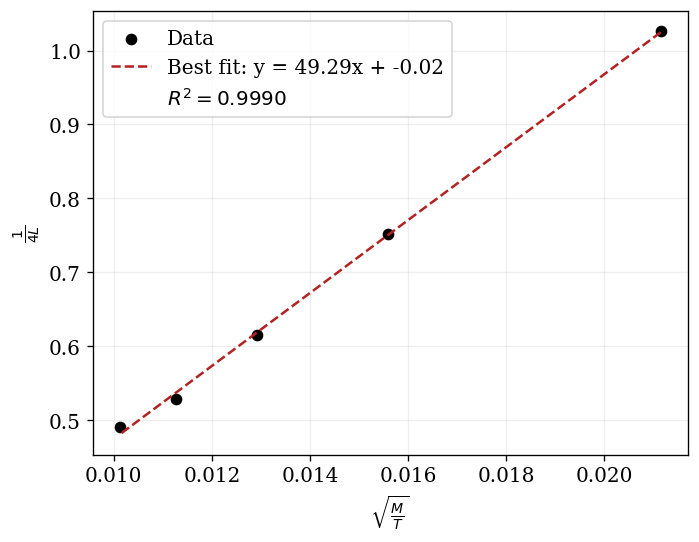

In [336]:
L_avg = (L_val1 + L_val2 + L_val3) / 3
m3 = son(L_avg)

In [337]:
L_all = np.array([L_val1, L_val2, L_val3])

# Calculate SD for each of the 5 points
L_stdevs = np.std(L_all, axis=0)

print(L_stdevs)

[0.01528252 0.022291   0.00974109 0.00496655 0.01108553]


In [338]:
def plot_with_errors(L1, L2, L3):
    # 1. Stack and calculate statistics for the 5 points
    L_all = np.array([L1, L2, L3])
    L_avg = np.mean(L_all, axis=0)
    L_std = np.std(L_all, axis=0)
    
    # 2. Physics Constants
    M_son = np.array([0.513, 1.025, 1.538, 2.051, 2.565])
    T_son = (M_son + 0.096) * 9.81
    specmass = 0.2673 / 1000
    speclength = 10 / 100
    mperL_son = specmass / speclength
    
    # 3. Calculate Coordinates
    y_son = 1 / (4 * L_avg)
    x_son = np.sqrt(mperL_son / T_son)
    
    # 4. Propagate Error for Y-axis: delta(y) = sigma_L / (4 * L^2)
    y_err = L_std / (4 * L_avg**2)
    
    # 5. Linear Fit
    m, c = np.polyfit(x_son, y_son, deg=1)
    y_fit = m * x_son + c
    
    
    # Plot data points with error bars
    plt.errorbar(x_son, y_son, yerr=y_err, fmt='o', color='black', 
                 ecolor='firebrick', elinewidth=1.5, capsize=4, 
                 label="Data with $\sigma_L$ Error Bars")
    
    # Plot best fit line
    plt.plot(x_son, y_fit, color='navy', linestyle='--', 
             label=f"Best Fit: $y = {m:.2f}x - {abs(c):.2f}$")
    
    plt.xlabel(r"$\sqrt{\frac{m}{T}}$", fontsize=12)
    plt.ylabel(r"$\frac{1}{4L}$", fontsize=12)
    plt.grid(True, alpha=0.4)
    plt.legend()
    
    return m, L_std

# Call the function with your arrays
# freq_val, deviations = plot_with_errors(L_val1, L_val2, L_val3)

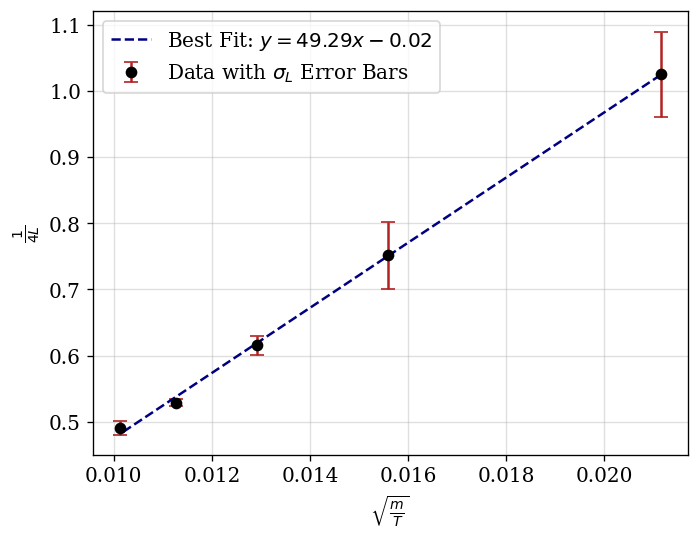

In [353]:
plot_with_errors(L_val1,L_val2,L_val3)
plt.savefig("Sonometer.jpg")

In [340]:
#Percentage Error:
err3 = (m3 - 50)/50 * 100
print('Percentage Error:',err3.round(3),'%')

Percentage Error: -1.423 %


# Part III - Resonance Tube

In [341]:
def getharmonic(f, L=0):
    #Takes f value and gives all the lengths corresponding to its harmonics in order 1, 3, 5.
    # Has optional argument L to find relative difference of your length to each harmonic
    #Use to identify which harmonic you are looking at. 
    w = 343/f
    l1 = [w/4, 3*w/4, 5*w/4]
    res = []
    for i in l1:
        res.append(i-L)
    return(res)

def getc(L,h,f):
    #Takes observed length, its corresponding harmonic and the frequency of tuning fork used. 
    #Returns the speed of sound obtained from them.
    w = 4*L/h
    speed = f*w
    return w

def allgetc(freq, Larr=[]):
    cvals = []
    for j in Larr:
        res1 = getharmonic(f=freq, L=j)
        hindex = [1,3,5]
        h = np.argmin(np.abs(res1))
        harm = hindex[h]
        findc = getc(L=j, h=harm, f=freq)
        cvals.append(findc)
    return(np.array(cvals))


In [342]:
L_512 = np.array([16.5,48.9, 82.9])/100
allgetc(512,L_512)

array([0.66  , 0.652 , 0.6632])

In [343]:
L_480 = np.array([17.7,53.2,88.7])/100
allgetc(480,L_480)

array([0.708     , 0.70933333, 0.7096    ])

In [344]:
L_426 = np.array([18.3, 59.5,99.7])/100
allgetc(426.6, L_426)

array([0.732     , 0.79333333, 0.7976    ])

In [345]:
L_384 = np.array([20.9,66.2])/100
allgetc(384, L_384)

array([0.836     , 0.88266667])

In [346]:
L_341 = np.array([24.5,75.3])/100
allgetc(341.3, L_341)

array([0.98 , 1.004])

In [347]:
L_320 = np.array([25.8, 80.2])/100
allgetc(320, L_320)

array([1.032     , 1.06933333])

In [348]:
L_288 = np.array([29.4,88.5])/100
allgetc(288, L_288)

array([1.176, 1.18 ])

In [349]:
L_256 = np.array([33.3,99.5])/100
allgetc(256,L_256)

array([1.332     , 1.32666667])

349.94591600938696


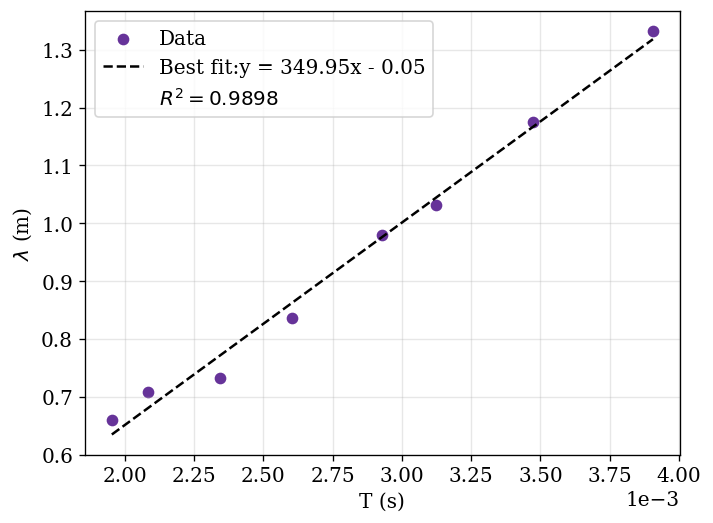

In [350]:
H1_lambda = np.array([0.66, 0.708, 0.732, 0.836, 0.98, 1.032, 1.176, 1.332])
freqs = np.array([512, 480, 426.6, 384, 341.3, 320, 288, 256])
times = 1/freqs
plt.scatter(times, H1_lambda, c="rebeccapurple",label="Data")
m,c = np.polyfit(times, H1_lambda, deg=1)
y_fith1 = m*times + c
plt.plot(times, y_fith1, ls="--",c='k', label=fr"Best fit:y = {m:.2f}x - {abs(c):.2f}")
rsq_h1 = rsq(H1_lambda,y_fith1)
plt.plot([], [], ' ', label=fr"$R^2 = {rsq_h1:.4f}$")
plt.xlabel("T (s)")
plt.ylabel(r"$\lambda$ (m)")
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.legend()
print(m)
plt.grid(alpha=0.3)
# plt.savefig("harmc_1.jpg")

349.94591600938696
343.86231802599076


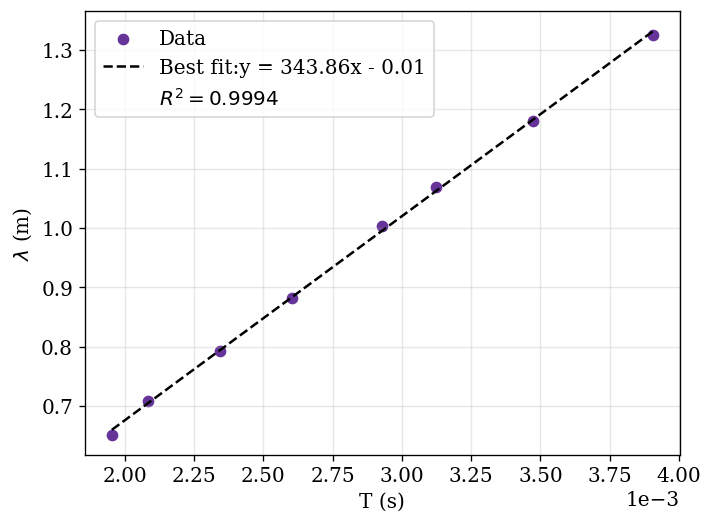

In [351]:
H2_lambda = np.array([0.652, 0.709, 0.793, 0.882, 1.004, 1.069, 1.18, 1.326])
plt.scatter(times, H2_lambda, c='rebeccapurple',label="Data")

m2,c2 = np.polyfit(times, H2_lambda, deg=1)
y_fith2 = m2*times + c2
plt.plot(times, y_fith2, ls="--",c='k',label=fr"Best fit:y = {m2:.2f}x - {abs(c2):.2f}")
rsq_h2 = rsq(H2_lambda,y_fith2)
plt.plot([], [], ' ', label=fr"$R^2 = {rsq_h2:.4f}$")
plt.xlabel("T (s)")
plt.ylabel(r"$\lambda$ (m)")
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.legend()
print(m)
print(m2)
plt.grid(alpha=0.3)
# plt.savefig("harmc_2.jpg")

[0.00195312 0.00208333 0.00234412]


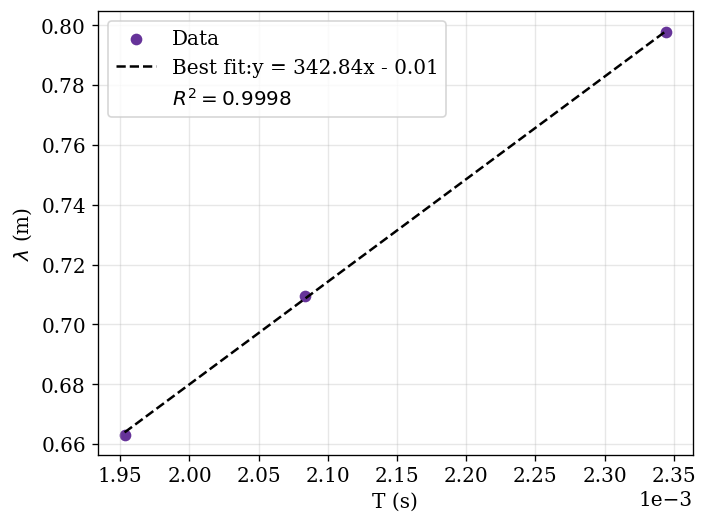

In [352]:
H3_lambda = np.array([0.6632,0.7096, 0.7976])
plt.scatter(times[:3], H3_lambda, c="rebeccapurple",label="Data")

m3,c3 = np.polyfit(times[:3], H3_lambda, deg=1)
y_fith3 = m3*times[:3] + c3
plt.plot(times[:3], y_fith3, ls="--",c="k",label=fr"Best fit:y = {m3:.2f}x - {abs(c3):.2f}")
rsq_h3 = rsq(H3_lambda,y_fith3)
plt.plot([], [], ' ', label=fr"$R^2 = {rsq_h3:.4f}$")
plt.xlabel("T (s)")
plt.ylabel(r"$\lambda$ (m)")
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.legend()
print(times[:3])
plt.grid(alpha = 0.3)
# plt.savefig("harmc_3.jpg")